# Validación de los modelos de idoneidad agrícola

Este notebook amplía la evaluación de los modelos LightGBM entrenados por región.
Además del split geográfico por condados usado en el entrenamiento, se aplican
cuatro validaciones adicionales que aportan una visión más completa de la calidad
y la robustez del sistema:

1. **Validación cruzada espacial por bloques** — comprueba que el rendimiento no
   depende de una única partición de condados.
2. **Análisis de residuos** — identifica dónde y cómo se equivocan los modelos.
3. **Importancia de variables (SHAP)** — explica en qué se apoya cada modelo.
4. **Comparación con un modelo global** — justifica el enfoque regionalizado.

Los modelos ya entrenados se cargan desde `models/lightgbm_final/`.

## 1. Configuración

In [1]:
import os
import json
import joblib
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Rutas (las mismas del notebook de modelado)
RUTA_DATOS = "../Data/"
MODELS_DIR = "../models/"
LGB_DIR    = os.path.join(MODELS_DIR, "lightgbm_final")
OUTPUT_DIR = "C:/Users/lesli/Documents/TFM/notebooks/ML_outputs"
FIG_DIR    = os.path.join(OUTPUT_DIR, "figuras_latex")
os.makedirs(FIG_DIR, exist_ok=True)

etiquetas_cluster = {
    0: "Montaña / clima frío",
    1: "Zona templada húmeda",
    2: "Valle cálido — suelo arenoso",
    3: "Valle cálido — suelo arcilloso",
    4: "Desierto árido",
}

# Features base (idénticas al entrenamiento)
features_base = [
    "tmax", "tmin", "ppt",
    "ph1to1h2o_r", "awc_r",
    "profundidad_efectiva_cm",
    "claytotal_r", "dbthirdbar_r",
    "sandtotal_r", "silttotal_r",
]

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "serif", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
})

def guardar_figura(fig, nombre):
    ruta = os.path.join(FIG_DIR, f"{nombre}.pdf")
    fig.savefig(ruta, format="pdf", bbox_inches="tight")
    print(f"Figura guardada: {ruta}")

COLOR = "#1D9E75"
COLOR2 = "#0F6E56"
COLOR3 = "#D85A30"

In [2]:
def wmape(y_true, y_pred):
    """Error porcentual absoluto ponderado."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else 100.0 * np.sum(np.abs(y_true - y_pred)) / denom

def calcular_metricas(y_true, y_pred):
    return {
        "r2":    r2_score(y_true, y_pred),
        "wmape": wmape(y_true, y_pred),
        "rmse":  np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae":   mean_absolute_error(y_true, y_pred),
    }

## 2. Carga de datos y modelos entrenados

In [3]:
# Dataset con clusters, condados y el IAI objetivo
df = pl.read_parquet(os.path.join(RUTA_DATOS, "df_cluster.parquet"))
print("Filas:", df.shape[0])
print("Clusters:", sorted(df["cluster"].unique().to_list()))
print("Condados:", df["county"].n_unique())

Filas: 633904
Clusters: [0, 1, 2, 3, 4]
Condados: 57


In [4]:
# Cargar los modelos LightGBM finales y su lista de features
modelos = {}
features_por_cluster = {}
for c in etiquetas_cluster:
    modelos[c] = joblib.load(os.path.join(LGB_DIR, f"modelo_cluster_{c}_lgb.pkl"))
    with open(os.path.join(LGB_DIR, f"features_cluster_{c}.json")) as f:
        features_por_cluster[c] = json.load(f)
    print(f"Cluster {c} ({etiquetas_cluster[c]}): modelo cargado, "
          f"{len(features_por_cluster[c])} features")

Cluster 0 (Montaña / clima frío): modelo cargado, 22 features
Cluster 1 (Zona templada húmeda): modelo cargado, 22 features
Cluster 2 (Valle cálido — suelo arenoso): modelo cargado, 22 features
Cluster 3 (Valle cálido — suelo arcilloso): modelo cargado, 22 features
Cluster 4 (Desierto árido): modelo cargado, 20 features


In [5]:
def preparar_datos_cluster(c):
    """Devuelve X, y, condados y cultivos de un cluster, con las columnas one-hot
    en el mismo orden que espera el modelo guardado."""
    df_c = df.filter(pl.col("cluster") == c).to_dummies(columns=["crop_name"])
    feats = features_por_cluster[c]
    # Asegurar que existen todas las columnas one-hot que el modelo espera
    for col in feats:
        if col not in df_c.columns:
            df_c = df_c.with_columns(pl.lit(0).alias(col))
    X = df_c.select(feats).to_numpy()
    y = df_c.select("IAI").to_numpy().ravel()
    condados = df_c.select("county").to_numpy().ravel()
    # crop_name original para análisis por cultivo
    df_c_orig = df.filter(pl.col("cluster") == c)
    cultivos = df_c_orig.select("crop_name").to_numpy().ravel()
    return X, y, condados, cultivos

# Preparar todos los clusters una vez
datos = {c: preparar_datos_cluster(c) for c in etiquetas_cluster}
print("Datos preparados para los 5 clusters.")

Datos preparados para los 5 clusters.


## 3. Validación cruzada espacial por bloques

El entrenamiento usó una única división de condados en train/val/test. Para
comprobar que el rendimiento no depende de esa partición concreta, se realiza una
validación cruzada espacial: los condados de cada cluster se reparten en cinco
bloques y, en cada iteración, se entrena con cuatro bloques y se evalúa en el
que queda fuera. Como los condados de test nunca aparecen en el entrenamiento,
esta estrategia mide la capacidad de generalizar a zonas no vistas.

Se usan los mismos hiperparámetros del modelo final de cada cluster, de modo que
lo que se evalúa es la estabilidad del rendimiento ante distintas particiones
del territorio.

In [6]:
from sklearn.model_selection import GroupKFold

N_FOLDS = 5

def cv_espacial_cluster(c, n_folds=N_FOLDS):
    """Validación cruzada espacial por condados para un cluster.
    Reutiliza los hiperparámetros del modelo final ya entrenado."""
    X, y, condados, _ = datos[c]

    # Si el cluster tiene menos condados que folds, se ajusta el número de folds
    n_cond = len(np.unique(condados))
    folds = min(n_folds, n_cond)
    if folds < 2:
        return None  # no hay condados suficientes para CV

    # Hiperparámetros del modelo final de este cluster
    params = modelos[c].get_params()

    gkf = GroupKFold(n_splits=folds)
    metricas_folds = []
    for i, (idx_tr, idx_te) in enumerate(gkf.split(X, y, groups=condados)):
        modelo = lgb.LGBMRegressor(**params)
        modelo.fit(X[idx_tr], y[idx_tr])
        pred = modelo.predict(X[idx_te])
        m = calcular_metricas(y[idx_te], pred)
        metricas_folds.append(m)
    return pd.DataFrame(metricas_folds)

In [7]:
# Ejecutar la CV espacial en cada cluster
filas_cv = []
for c in etiquetas_cluster:
    res = cv_espacial_cluster(c)
    if res is None:
        print(f"Cluster {c}: condados insuficientes para CV")
        continue
    filas_cv.append({
        "cluster": c,
        "etiqueta": etiquetas_cluster[c],
        "r2_medio": res["r2"].mean(),
        "r2_std": res["r2"].std(),
        "wmape_medio": res["wmape"].mean(),
        "wmape_std": res["wmape"].std(),
    })
    print(f"Cluster {c} ({etiquetas_cluster[c]}): "
          f"R² = {res['r2'].mean():.3f} ± {res['r2'].std():.3f} | "
          f"WMAPE = {res['wmape'].mean():.2f}% ± {res['wmape'].std():.2f}")

df_cv = pd.DataFrame(filas_cv)
print()
print(df_cv.round(3).to_string(index=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002799 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1478
[LightGBM] [Info] Number of data points in the train set: 35170, number of used features: 18
[LightGBM] [Info] Start training from score 0.680324


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004355 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1489
[LightGBM] [Info] Number of data points in the train set: 35424, number of used features: 18
[LightGBM] [Info] Start training from score 0.686371


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 36099, number of used features: 18
[LightGBM] [Info] Start training from score 0.673994


...

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001526 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1223
[LightGBM] [Info] Number of data points in the train set: 41351, number of used features: 17
[LightGBM] [Info] Start training from score 0.546591
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1227
[LightGBM] [Info] Number of data points in the train set: 41360, number of used features: 17
[LightGBM] [Info] Start training from score 0.546637
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


C:\Users\lesli\AppData\Local\Temp\ipykernel_37800\1475423707.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\val_cv_espacial_r2.pdf


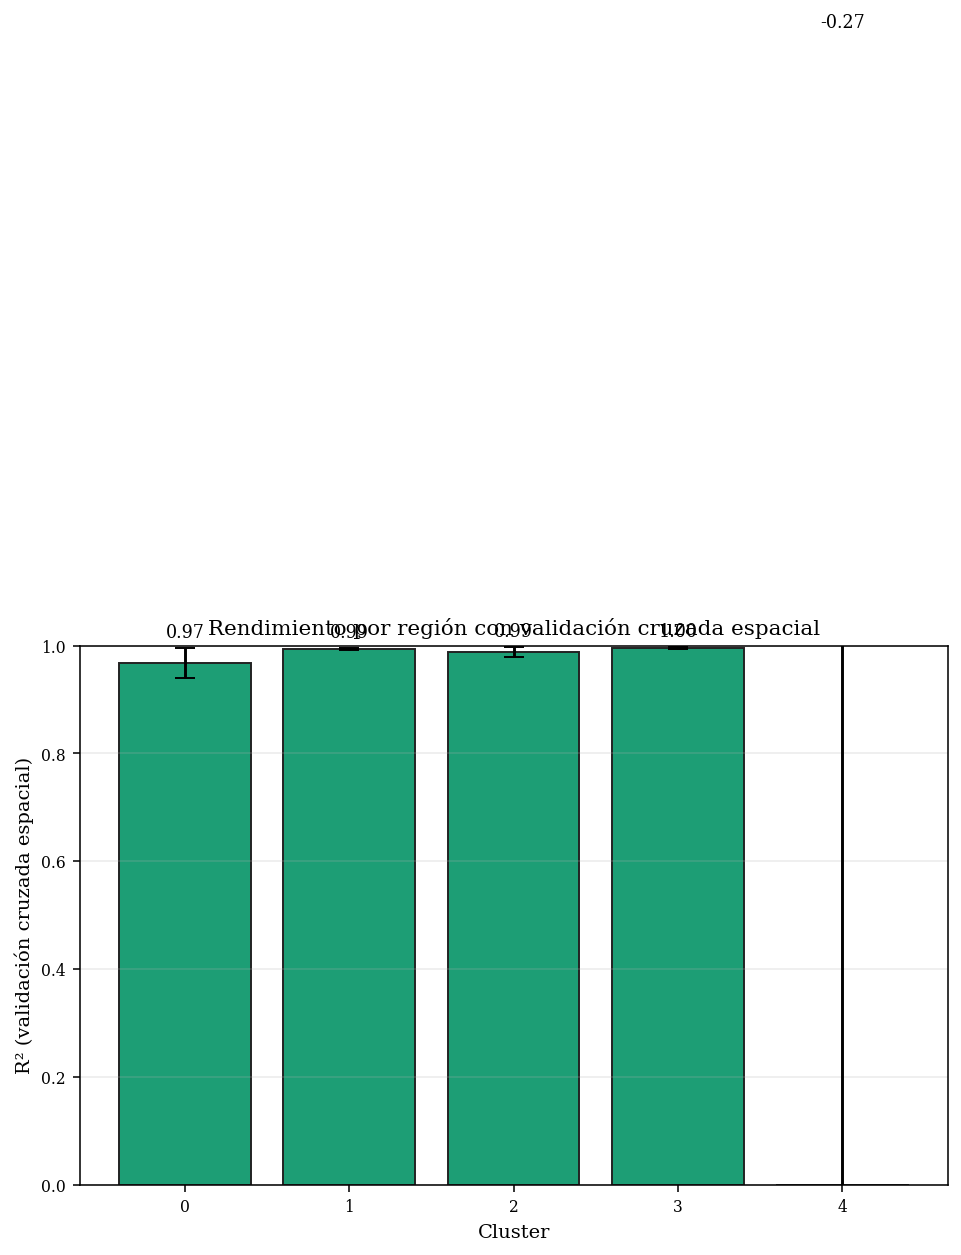

In [8]:
# Gráfico: R² medio por cluster con su variabilidad (barras de error)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_cv["cluster"].astype(str), df_cv["r2_medio"],
       yerr=df_cv["r2_std"], capsize=5, color=COLOR, edgecolor="#222")
ax.set_xlabel("Cluster")
ax.set_ylabel("R² (validación cruzada espacial)")
ax.set_title("Rendimiento por región con validación cruzada espacial")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
for i, row in df_cv.iterrows():
    ax.text(i, row["r2_medio"] + row["r2_std"] + 0.02,
            f"{row['r2_medio']:.2f}", ha="center", fontsize=9)
plt.tight_layout()
guardar_figura(fig, "val_cv_espacial_r2")
plt.show()

## 4. Análisis de residuos

Se analizan los errores del modelo sobre el conjunto de datos completo, usando la
predicción de cada modelo sobre su propio cluster. El objetivo es ver si los
errores se distribuyen de forma homogénea o si hay patrones, tanto en el rango del
índice como entre cultivos.

In [9]:
# Predicción de cada modelo sobre su cluster y cálculo de residuos
y_real, y_pred, cluster_id, cultivo_id = [], [], [], []
for c in etiquetas_cluster:
    X, y, _, cultivos = datos[c]
    pred = modelos[c].predict(X)
    y_real.append(y)
    y_pred.append(pred)
    cluster_id.append(np.full(len(y), c))
    cultivo_id.append(cultivos)

y_real = np.concatenate(y_real)
y_pred = np.concatenate(y_pred)
cluster_id = np.concatenate(cluster_id)
cultivo_id = np.concatenate(cultivo_id)
residuos = y_real - y_pred

print(f"Observaciones evaluadas: {len(y_real):,}")
print(f"Residuo medio: {residuos.mean():.4f}")
print(f"Desviación de los residuos: {residuos.std():.4f}")

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

Observaciones evaluadas: 633,904
Residuo medio: -0.0001
Desviación de los residuos: 0.0049


Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\val_residuos.pdf


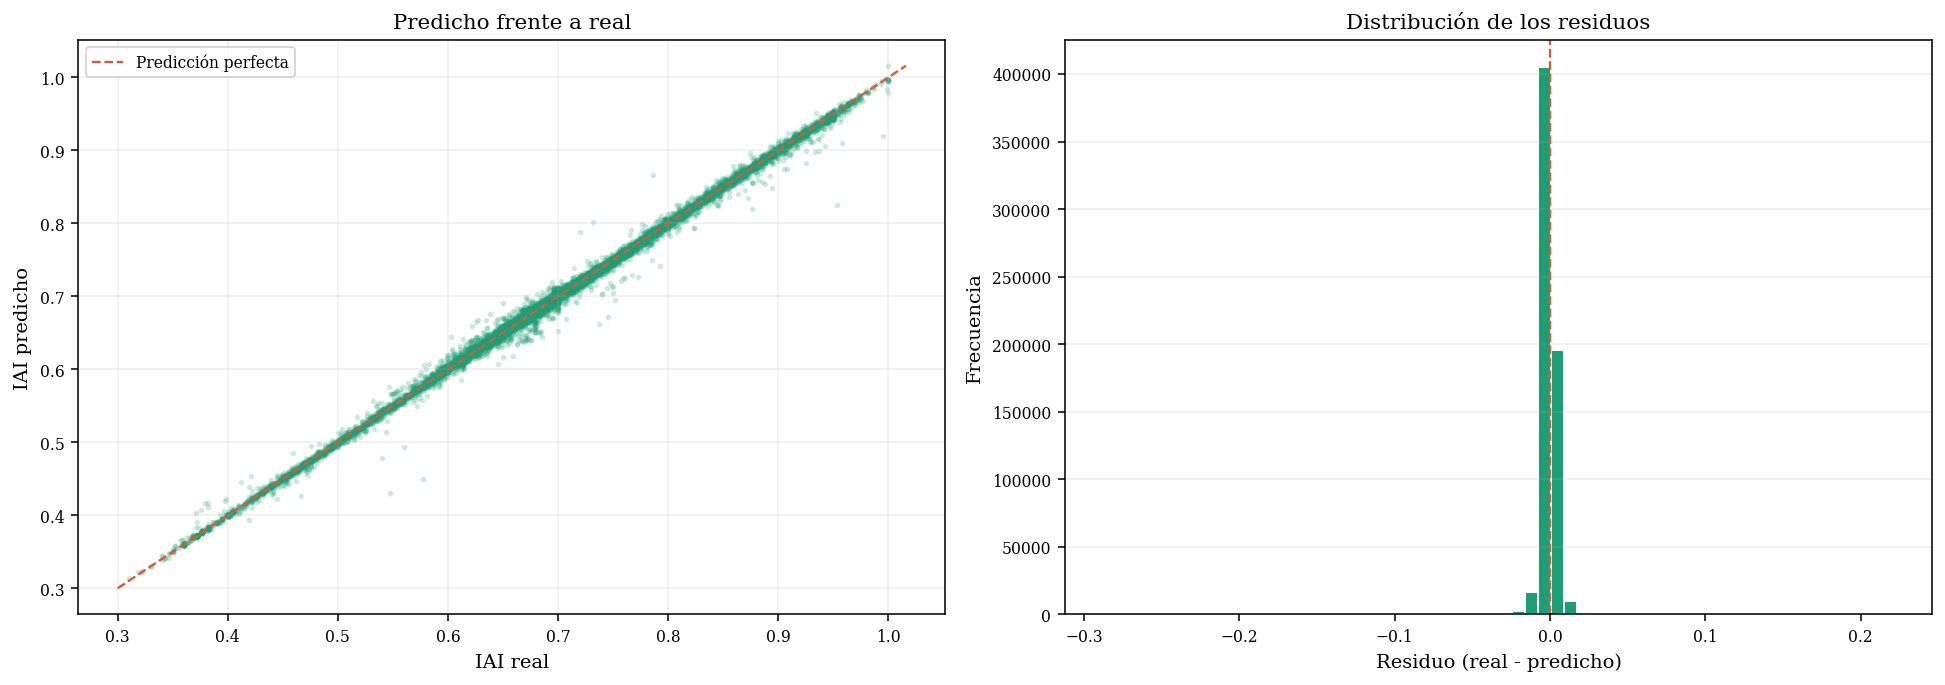

In [10]:
# Gráfico 1: predicho vs real | Gráfico 2: distribución de residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicho vs real (muestra para no saturar)
np.random.seed(42)
idx = np.random.choice(len(y_real), size=min(20000, len(y_real)), replace=False)
axes[0].scatter(y_real[idx], y_pred[idx], s=4, alpha=0.15, color=COLOR)
lims = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
axes[0].plot(lims, lims, "--", color=COLOR3, linewidth=1.2, label="Predicción perfecta")
axes[0].set_xlabel("IAI real")
axes[0].set_ylabel("IAI predicho")
axes[0].set_title("Predicho frente a real")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Histograma de residuos
axes[1].hist(residuos, bins=60, color=COLOR, edgecolor="white")
axes[1].axvline(0, color=COLOR3, linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Residuo (real - predicho)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de los residuos")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
guardar_figura(fig, "val_residuos")
plt.show()

Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\val_error_por_cultivo.pdf


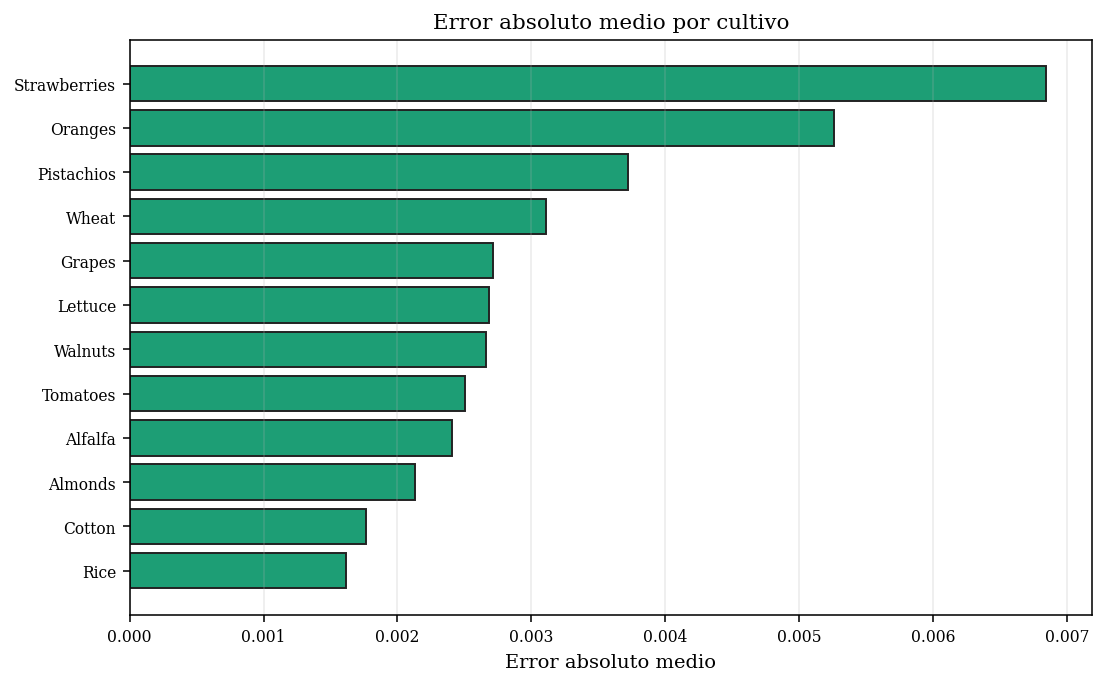

Error absoluto medio por cultivo:
cultivo
Strawberries    0.0068
Oranges         0.0053
Pistachios      0.0037
Wheat           0.0031
Grapes          0.0027
Lettuce         0.0027
Walnuts         0.0027
Tomatoes        0.0025
Alfalfa         0.0024
Almonds         0.0021
Cotton          0.0018
Rice            0.0016


In [11]:
# Error absoluto medio por cultivo
df_res = pd.DataFrame({
    "cultivo": cultivo_id,
    "abs_error": np.abs(residuos),
})
err_cultivo = (df_res.groupby("cultivo")["abs_error"]
               .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(err_cultivo.index, err_cultivo.values, color=COLOR, edgecolor="#222")
ax.set_xlabel("Error absoluto medio")
ax.set_title("Error absoluto medio por cultivo")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
guardar_figura(fig, "val_error_por_cultivo")
plt.show()

print("Error absoluto medio por cultivo:")
print(err_cultivo.round(4).to_string())

## 5. Importancia de variables (SHAP)

Para entender en qué se apoya cada modelo, se calculan los valores SHAP, que
cuantifican la contribución de cada variable a las predicciones. Se analiza cada
cluster por separado, ya que las regiones tienen condiciones distintas y los
modelos pueden apoyarse en variables diferentes.

In [12]:
import shap

def shap_cluster(c, n_muestra=2000):
    """Calcula y grafica la importancia SHAP de un cluster."""
    X, y, _, _ = datos[c]
    feats = features_por_cluster[c]
    # Muestra para acelerar
    n = min(n_muestra, X.shape[0])
    idx = np.random.choice(X.shape[0], size=n, replace=False)
    X_s = X[idx]

    explainer = shap.TreeExplainer(modelos[c])
    shap_vals = explainer.shap_values(X_s)

    fig = plt.figure()
    shap.summary_plot(shap_vals, X_s, feature_names=feats,
                      show=False, max_display=12)
    plt.title(f"SHAP — Cluster {c}: {etiquetas_cluster[c]}", fontsize=11)
    plt.tight_layout()
    guardar_figura(fig, f"val_shap_cluster_{c}")
    plt.show()

    # Importancia media absoluta por variable
    imp = np.abs(shap_vals).mean(axis=0)
    return pd.Series(imp, index=feats).sort_values(ascending=False)

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\lesli\AppData\Local\Temp\ipykernel_37800\2627281109.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_s, feature_names=feats,


Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\val_shap_cluster_0.pdf


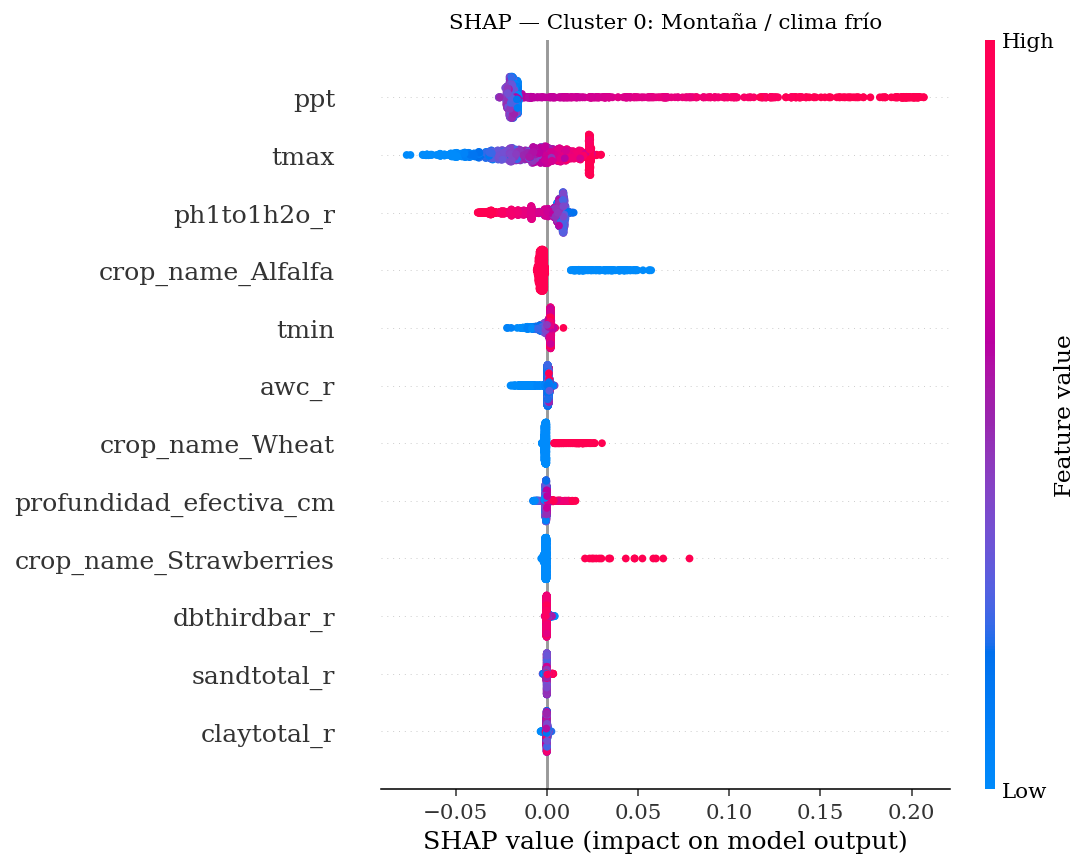

Top variables del cluster 0:
ppt                        0.0334
tmax                       0.0179
ph1to1h2o_r                0.0102
crop_name_Alfalfa          0.0051
tmin                       0.0026
awc_r                      0.0017
crop_name_Wheat            0.0017
profundidad_efectiva_cm    0.0010
crop_name_Strawberries     0.0009
dbthirdbar_r               0.0003


In [21]:
# SHAP del cluster 0 
np.random.seed(42)
imp_c0 = shap_cluster(0)
print("Top variables del cluster 0:")
print(imp_c0.head(10).round(4).to_string())

C:\Users\lesli\AppData\Local\Temp\ipykernel_37800\2627281109.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_s, feature_names=feats,


Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\val_shap_cluster_1.pdf


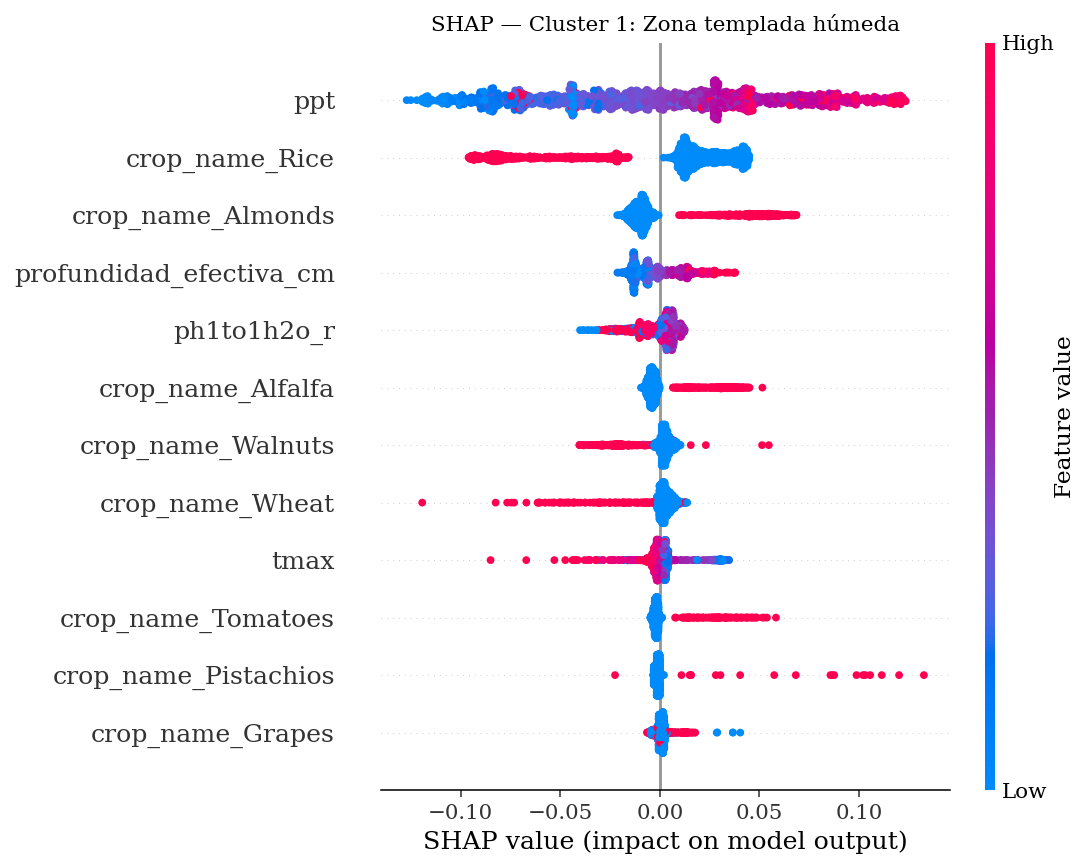

Top variables del cluster 1:
ppt                        0.0506
crop_name_Rice             0.0337
crop_name_Almonds          0.0168
profundidad_efectiva_cm    0.0102
ph1to1h2o_r                0.0068
crop_name_Alfalfa          0.0066
crop_name_Walnuts          0.0053
crop_name_Wheat            0.0045
tmax                       0.0038
crop_name_Tomatoes         0.0034


In [22]:
# SHAP del cluster 1
np.random.seed(42)
imp_c1 = shap_cluster(1)
print("Top variables del cluster 1:")
print(imp_c1.head(10).round(4).to_string())

C:\Users\lesli\AppData\Local\Temp\ipykernel_37800\2627281109.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_s, feature_names=feats,


Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\val_shap_cluster_2.pdf


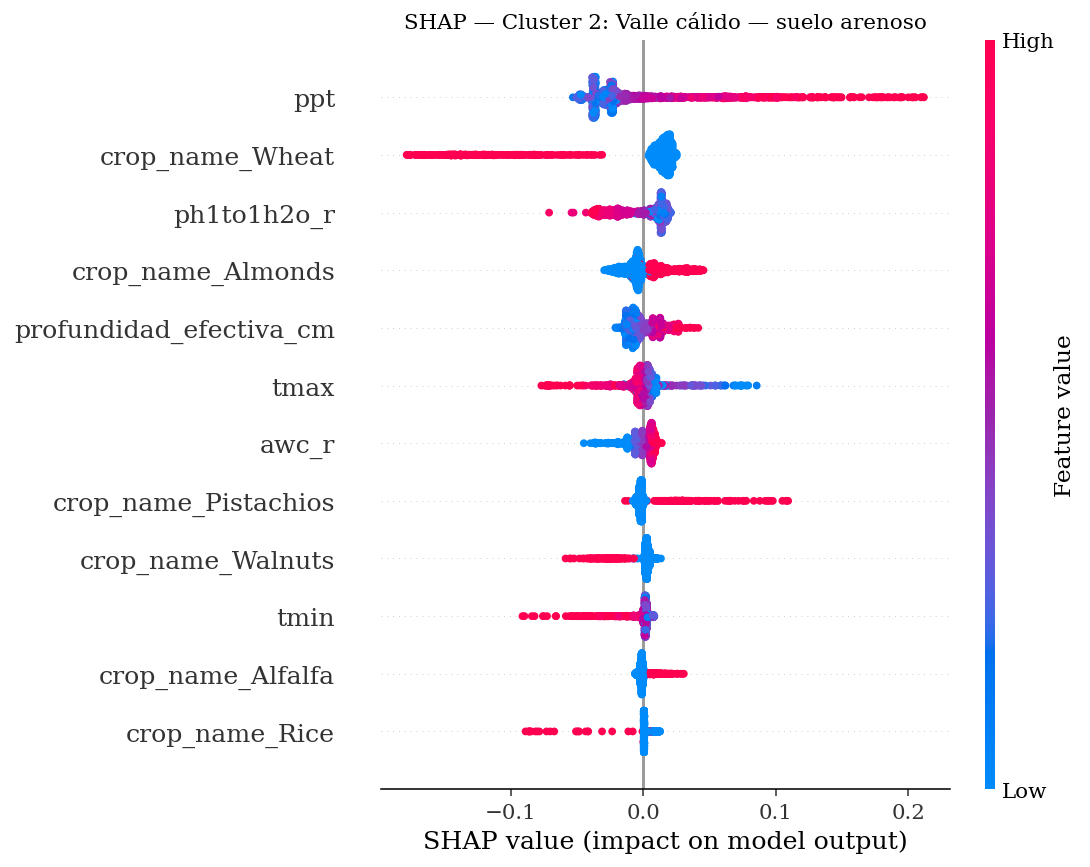

Top variables del cluster 2:
ppt                        0.0362
crop_name_Wheat            0.0262
ph1to1h2o_r                0.0162
crop_name_Almonds          0.0107
profundidad_efectiva_cm    0.0093
tmax                       0.0069
awc_r                      0.0067
crop_name_Pistachios       0.0048
crop_name_Walnuts          0.0047
tmin                       0.0044


In [24]:
# SHAP del cluster 2
np.random.seed(42)
imp_c2 = shap_cluster(2)
print("Top variables del cluster 2:")
print(imp_c2.head(10).round(4).to_string())

C:\Users\lesli\AppData\Local\Temp\ipykernel_37800\2627281109.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_s, feature_names=feats,


Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\val_shap_cluster_3.pdf


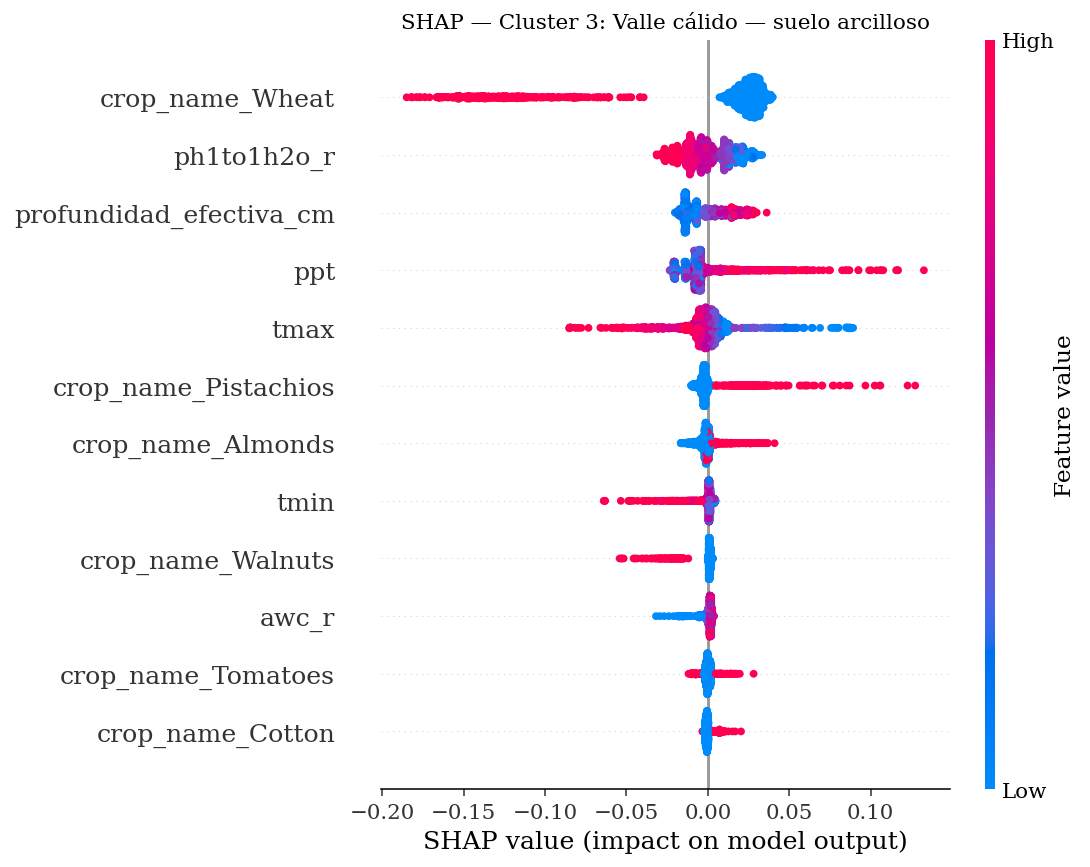

Top variables del cluster 3:
crop_name_Wheat            0.0430
ph1to1h2o_r                0.0118
profundidad_efectiva_cm    0.0117
ppt                        0.0115
tmax                       0.0090
crop_name_Pistachios       0.0060
crop_name_Almonds          0.0033
tmin                       0.0027
crop_name_Walnuts          0.0022
awc_r                      0.0020


In [25]:
# SHAP del cluster 3 (Valle arcilloso, con frutales de frío)
np.random.seed(42)
imp_c3 = shap_cluster(3)
print("Top variables del cluster 3:")
print(imp_c3.head(10).round(4).to_string())

C:\Users\lesli\AppData\Local\Temp\ipykernel_37800\2627281109.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_s, feature_names=feats,


Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\val_shap_cluster_4.pdf


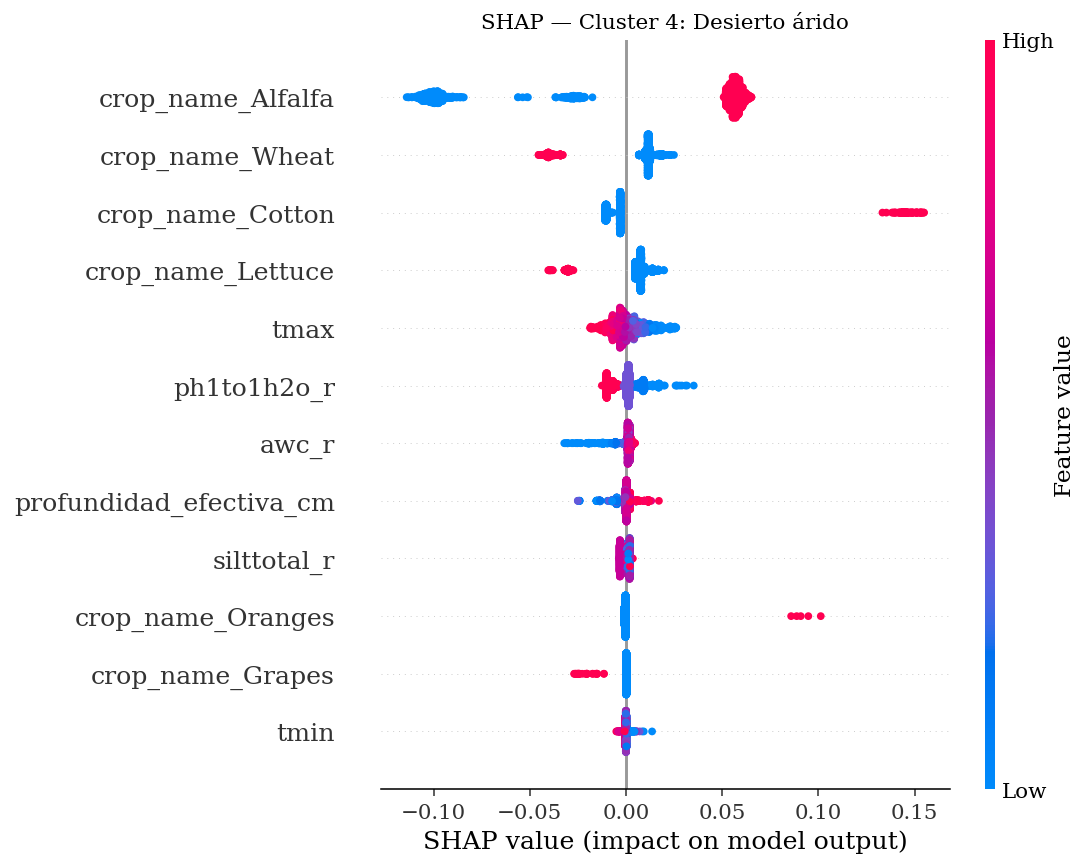

Top variables del cluster 4:
crop_name_Alfalfa          0.0675
crop_name_Wheat            0.0169
crop_name_Cotton           0.0129
crop_name_Lettuce          0.0099
tmax                       0.0060
ph1to1h2o_r                0.0047
awc_r                      0.0026
profundidad_efectiva_cm    0.0022
silttotal_r                0.0015
crop_name_Oranges          0.0007


In [27]:
# SHAP del cluster 1
np.random.seed(42)
imp_c4 = shap_cluster(4)
print("Top variables del cluster 4:")
print(imp_c4.head(10).round(4).to_string())

In [14]:
# SHAP de todos los clusters: tabla de las 5 variables más importantes por región
resumen_shap = {}
for c in etiquetas_cluster:
    np.random.seed(42)
    X, _, _, _ = datos[c]
    feats = features_por_cluster[c]
    n = min(2000, X.shape[0])
    idx = np.random.choice(X.shape[0], size=n, replace=False)
    explainer = shap.TreeExplainer(modelos[c])
    sv = explainer.shap_values(X[idx])
    imp = pd.Series(np.abs(sv).mean(axis=0), index=feats).sort_values(ascending=False)
    resumen_shap[c] = imp.head(5).index.tolist()

print("Cinco variables más influyentes por cluster:\n")
for c, top in resumen_shap.items():
    print(f"Cluster {c} ({etiquetas_cluster[c]}):")
    print(f"   {', '.join(top)}\n")

Cinco variables más influyentes por cluster:

Cluster 0 (Montaña / clima frío):
   ppt, tmax, ph1to1h2o_r, crop_name_Alfalfa, tmin

Cluster 1 (Zona templada húmeda):
   ppt, crop_name_Rice, crop_name_Almonds, profundidad_efectiva_cm, ph1to1h2o_r

Cluster 2 (Valle cálido — suelo arenoso):
   ppt, crop_name_Wheat, ph1to1h2o_r, crop_name_Almonds, profundidad_efectiva_cm

Cluster 3 (Valle cálido — suelo arcilloso):
   crop_name_Wheat, ph1to1h2o_r, profundidad_efectiva_cm, ppt, tmax

Cluster 4 (Desierto árido):
   crop_name_Alfalfa, crop_name_Wheat, crop_name_Cotton, crop_name_Lettuce, tmax



## 6. Comparación con un modelo global

El sistema entrena un modelo por región. Para justificar este enfoque, se compara
con un modelo global único, entrenado sobre todos los datos sin distinguir
regiones. Si el enfoque regionalizado aporta valor, debería igualar o superar al
modelo global.

La comparación se realiza sobre el mismo esquema espacial: se separan condados
para test y se mide el rendimiento agregado de ambos enfoques sobre esas mismas
parcelas de test.

In [15]:
from sklearn.model_selection import GroupKFold

# Preparar un dataset global con las mismas features + one-hot de cultivo y el cluster
df_global = df.to_dummies(columns=["crop_name"])
cols_cultivo = sorted([col for col in df_global.columns if col.startswith("crop_name_")])
feats_global = features_base + cols_cultivo

X_g = df_global.select(feats_global).to_numpy()
y_g = df_global.select("IAI").to_numpy().ravel()
cond_g = df_global.select("county").to_numpy().ravel()
clus_g = df_global.select("cluster").to_numpy().ravel()

print("Dataset global:", X_g.shape)

Dataset global: (633904, 22)


In [16]:
# Un único split espacial (condados) para comparar ambos enfoques
gkf = GroupKFold(n_splits=5)
idx_tr, idx_te = next(gkf.split(X_g, y_g, groups=cond_g))

# --- Modelo global único ---
params_global = modelos[0].get_params()  # usar unos hiperparámetros de referencia
modelo_global = lgb.LGBMRegressor(**params_global)
modelo_global.fit(X_g[idx_tr], y_g[idx_tr])
pred_global = modelo_global.predict(X_g[idx_te])
m_global = calcular_metricas(y_g[idx_te], pred_global)

# --- Enfoque regionalizado (cada modelo predice su parte del test) ---
pred_region = np.zeros(len(idx_te))
clus_te = clus_g[idx_te]
for c in etiquetas_cluster:
    mask = clus_te == c
    if mask.sum() == 0:
        continue
    feats_c = features_por_cluster[c]
    # Alinear columnas del subconjunto de test al orden del modelo del cluster
    df_te = df_global[idx_te].to_pandas().reset_index(drop=True)
    for col in feats_c:
        if col not in df_te.columns:
            df_te[col] = 0
    X_te_c = df_te.loc[mask, feats_c].to_numpy()
    pred_region[mask] = modelos[c].predict(X_te_c)

m_region = calcular_metricas(y_g[idx_te], pred_region)

print("Comparación sobre las mismas parcelas de test:\n")
print(f"{'Enfoque':22s} {'R²':>8s} {'WMAPE':>8s} {'RMSE':>8s}")
print(f"{'Modelo global':22s} {m_global['r2']:>8.3f} {m_global['wmape']:>8.2f} {m_global['rmse']:>8.4f}")
print(f"{'Modelos por región':22s} {m_region['r2']:>8.3f} {m_region['wmape']:>8.2f} {m_region['rmse']:>8.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1620
[LightGBM] [Info] Number of data points in the train set: 507105, number of used features: 22
[LightGBM] [Info] Start training from score 0.690788


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

Comparación sobre las mismas parcelas de test:

Enfoque                      R²    WMAPE     RMSE
Modelo global             0.975     1.35   0.0141
Modelos por región        0.998     0.27   0.0036


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\val_global_vs_region.pdf


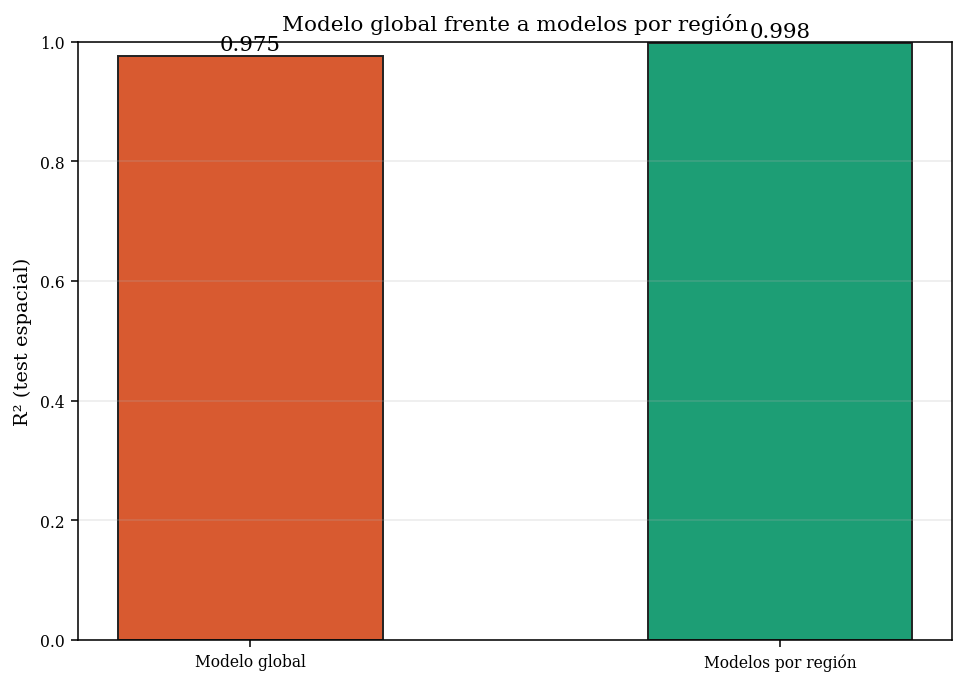

In [17]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(7, 5))
enfoques = ["Modelo global", "Modelos por región"]
r2s = [m_global["r2"], m_region["r2"]]
barras = ax.bar(enfoques, r2s, color=[COLOR3, COLOR], edgecolor="#222", width=0.5)
for b, v in zip(barras, r2s):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=11)
ax.set_ylabel("R² (test espacial)")
ax.set_title("Modelo global frente a modelos por región")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
guardar_figura(fig, "val_global_vs_region")
plt.show()

## 7. Síntesis de la validación

Las cuatro validaciones se complementan:

- La **validación cruzada espacial** indica si el rendimiento es estable ante
  distintas particiones del territorio.
- El **análisis de residuos** muestra dónde se concentran los errores.
- Los **valores SHAP** explican en qué variables se apoya cada modelo regional.
- La **comparación con el modelo global** justifica el enfoque regionalizado.

Los resultados numéricos de estas validaciones se recogen y se interpretan en la
sección de discusión de la memoria.